# Notebook 4: Tidsinhomogen coalescent og inferens

In [1]:
# Importer nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import Graph, with_ipv, StateIndexer, Property, LogGaussPrior, Adamelia, clear_caches  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 4)

clear_caches()

  Removed 3 file(s), preserved directory structure


In [2]:
# Kalibrerede SVGD-parametre fra NB02 
from phasic import ExpStepSize

BEST_LR_NAME   = 'Exp(0.1 → 0.001, τ=100)'
BEST_LR_KWARGS = {'learning_rate': ExpStepSize(0.1, 0.001, 100.0)}
BEST_ITER_LR   = 300
BEST_PRIOR     = 'DataPrior'
BEST_NOBS      = 10000
BEST_PARTICLES = 20

## Standard coalescent og epoch-mekanisme

Kingmans coalescent er tidshomogen — populationsparametrene er konstante. phasic understøtter tidsinhomogenitet via `add_epoch()` og `distribution_context()`. Jeg starter med at bygge den standard coalescent fra vejlederens kode og viser hvordan epoker tilføjes.

In [3]:
nr_samples = 4

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent)
N = BEST_NOBS
graph.update_weights([1/N])

## Populationsflaskehals: CDF via distribution_context

En flaskehals reducerer $N_e$ i et tidsinterval $[t_{\text{start}}, t_{\text{end}}]$. phasic modellerer dette via `distribution_context()` og `update_weights()` ved epoke-overgange. Jeg viser CDF-formen under varierende flaskehalsdybde.

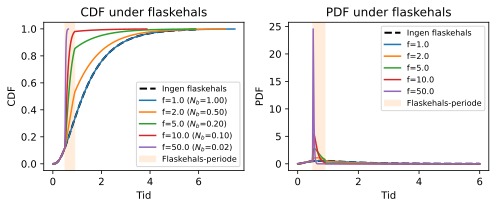

In [4]:
#| label: fig-bottleneck-cdf
#| fig-cap: 'CDF (venstre) og PDF (højre) for TMRCA under varierende flaskehals-dybde $f = N/N_b \in \{1, 2, 5, 10, 50\}$ med $n=4$. x-aksen viser tid i coalescent-enheder og y-aksen viser henholdsvis kumuleret sandsynlighed og tæthed. Hver kurve svarer til en flaskehals-dybde og den orange skravering markerer flaskehals-perioden. Stiplet sort kurve er referencen uden flaskehals.'
#| fig-width: 5
#| fig-height: 3

def compute_bottleneck_cdf(N, N_bottle, t_start, t_end, cdf_cutoff=0.999, granularity=None):
    graph = Graph(coalescent)
    param_changes = [
        (t_start, [1/N_bottle]),
        (t_end,   [1/N])
    ]
    cdf_vals, times = [], []
    ctx = graph.distribution_context()
    graph.update_weights([1/N])
    for change_time, new_params in param_changes:
        while ctx.time() < change_time:
            cdf_vals.append(ctx.cdf())
            times.append(ctx.time())
            ctx.step()
            if ctx.cdf() >= cdf_cutoff: break
        graph.update_weights(new_params)
    while ctx.cdf() < cdf_cutoff:
        cdf_vals.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()
    acc_occ = graph.accumulated_occupancy(max(times)*2)
    E = float(np.sum(acc_occ))
    return np.array(times), np.array(cdf_vals), E

N = 1.0
t_start, t_end = 0.5, 0.9

# Baseline: ingen flaskehals
graph_base = Graph(coalescent)
graph_base.update_weights([1/N])
t_vals = np.linspace(0, 6, 600)
cdf_base = graph_base.cdf(t_vals)

# Varierende flaskehals-dybde
depths = [1.0, 2.0, 5.0, 10.0, 50.0]  
fig, axes = plt.subplots(1, 2, figsize=(7,3))

axes[0].plot(t_vals, cdf_base, 'k--', lw=2, label='Ingen flaskehals')
axes[1].plot(t_vals, np.gradient(cdf_base, t_vals), 'k--', lw=2, label='Ingen flaskehals')

E_vals_depth = []
for f in depths:
    N_bottle = N / f
    t, cdf, E = compute_bottleneck_cdf(N, N_bottle, t_start, t_end)
    E_vals_depth.append({fr'Dybde $f=\frac{{N}}{{N_{{b}}}}$': f, r'$N_{bottle}$': round(N_bottle, 3), r'$\mathbb{E}[TMRCA]$': round(E, 4)})
    axes[0].plot(t, cdf, label=fr'f={f} ($N_b$={N_bottle:.2f})')
    pdf_approx = np.gradient(np.interp(t_vals, t, cdf), t_vals)
    axes[1].plot(t_vals, pdf_approx, label=f'f={f}')

for ax in axes:
    ax.axvspan(t_start, t_end, alpha=0.15, color='C1', label='Flaskehals-periode')

axes[0].set_xlabel('Tid'); axes[0].set_ylabel('CDF'); axes[0].set_title('CDF under flaskehals')
axes[0].legend(fontsize=8)
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('PDF'); axes[1].set_title('PDF under flaskehals')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show();



## Multi-epoch demografisk model

Jeg udvider til en serie af epoker med forskellige populationsstørrelser. Vejlederens kode bruger `add_epoch(time)` til at kæde epoker sammen og `update_weights()` til at sætte parametre per epoke.

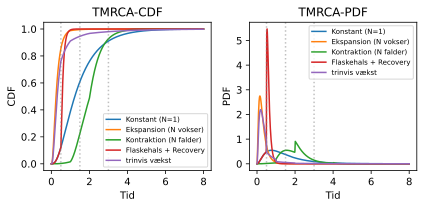

In [5]:
#| label: fig-multiepoch
#| fig-cap: 'CDF (venstre) og PDF (højre) for TMRCA under fem demografiske scenarier med $n=4$. x-aksen viser tid i coalescent-enheder og y-aksen viser henholdsvis kumuleret sandsynlighed og tæthed. Kurverne svarer til konstant population (blå), ekspansion hvor $N$ vokser bagud i tid (orange), kontraktion hvor $N$ falder bagud i tid (grøn), flaskehals med recovery (rød) og trinvis vækst (lilla). Stiplede grå linjer markerer epokegrænser.'
#| fig-width: 5
#| fig-height: 3

def multi_epoch_cdf(epoch_boundaries, pop_sizes, cdf_cutoff=0.9999):
    assert len(epoch_boundaries) == len(pop_sizes) - 1, "En grænse per overgang"
    graph = Graph(coalescent)
    graph.update_weights([1/pop_sizes[0]])
    changes = [(t, [1/N]) for t, N in zip(epoch_boundaries, pop_sizes[1:])]
    cdf_vals, times = [], []
    ctx = graph.distribution_context()
    for change_time, new_params in changes:
        while ctx.time() < change_time:
            cdf_vals.append(ctx.cdf())
            times.append(ctx.time())
            ctx.step()
            if ctx.cdf() >= cdf_cutoff: break
        graph.update_weights(new_params)
    while ctx.cdf() < cdf_cutoff:
        cdf_vals.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()
    return np.array(times), np.array(cdf_vals)

# Fire scenarier
scenarios = {
    f'Konstant (N=1)':        {'bounds': [1, 2, 4], 'sizes': [1, 1, 1, 1]},
    f'Ekspansion (N vokser)': {'bounds': [1, 2, 4], 'sizes': [0.2, 0.5, 1.0, 5.0]},
    f'Kontraktion (N falder)':{'bounds': [1, 2, 4], 'sizes': [5.0, 1.0, 0.5, 0.2]},
    f'Flaskehals + Recovery': {'bounds': [0.5, 1.5, 3], 'sizes': [1, 0.1, 0.1, 1]},
    f'trinvis vækst':        {'bounds': [0.5, 1.0, 2.0], 'sizes': [0.25, 0.5, 1.0, 2.0]},
}

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
t_fine = np.linspace(0, 8, 800)

for name, sc in scenarios.items():
    t, cdf = multi_epoch_cdf(sc['bounds'], sc['sizes'])
    cdf_interp = np.interp(t_fine, t, cdf)
    pdf_approx = np.gradient(cdf_interp, t_fine)
    axes[0].plot(t_fine, cdf_interp, label=name)
    axes[1].plot(t_fine, np.maximum(pdf_approx, 0), label=name)

# Marker epoker for flaskehals-scenariet
for b in [0.5, 1.5, 3]:
    axes[0].axvline(b, color='gray', linestyle=':', alpha=0.5)
    axes[1].axvline(b, color='gray', linestyle=':', alpha=0.5)

axes[0].set_xlabel('Tid'); axes[0].set_ylabel('CDF'); axes[0].set_title('TMRCA-CDF')
axes[0].legend(fontsize=7)
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('PDF'); axes[1].set_title('TMRCA-PDF')
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show();

## Epoch-mekanismen: add_epoch og StateIndexer

Vejlederens anbefalede tilgang til epoker bruger `StateIndexer` med `lineages` og `add_epoch()`. Jeg implementerer en 3-epoke model med $n=4$ og population-størrelser $N_e = [1, 5, 10]$ og beregner momenter og SFS.

In [6]:
from phasic import Graph, StateIndexer, Property

def coalescent_epoch(state, indexer=None):
    transitions = []
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if state.sum() <= 1: continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        k = indexer.props_to_index(ton=pi.ton + pj.ton)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

nr_samples_ep = 8
indexer_ep = StateIndexer(
    lineages=[Property('ton', min_value=1, max_value=nr_samples_ep)],
)
ipv_ep = [0] * indexer_ep.state_length
ipv_ep[indexer_ep.props_to_index(ton=1)] = nr_samples_ep

epoch_transitions = [0, 1, 2]
pop_sizes_ep = [1, 5, 10]

g_ep = Graph(coalescent_epoch, ipv=ipv_ep, indexer=indexer_ep)
g_ep.update_weights([pop_sizes_ep[0]])

weights = [pop_sizes_ep[0], 1]
for i in range(1, len(pop_sizes_ep)):
    g_ep = g_ep.add_epoch(epoch_transitions[i])
    weights.extend([1 / pop_sizes_ep[i], 1])
    g_ep.update_weights(weights)

print(f'Momenter (5 første): {g_ep.moments(5)}')

Momenter (5 første): [8.350952616779242, 164.68682715148117, 4963.184749223692, 198992.89702198672, 9958065.307981562]


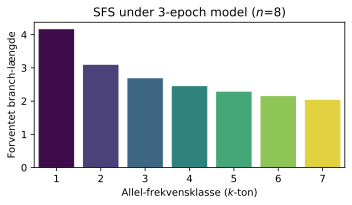

In [ ]:
#| label: fig-sfs-epoch
#| fig-cap: 'Forventet grenlængde per allel-frekvensklasse under en 3-epoke model med $n=8$. X-aksen viser frekvensklasse ($k$-ton) og y-aksen viser forventet grenlængde i coalescent-enheder. Hver søjle svarer til en frekvensklasse og er farvet efter frekvens fra lav (lilla) til høj (gul).'
#| fig-width: 5
#| fig-height: 3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

state_mat_ep = g_ep.states()
rewards_ep   = state_mat_ep[:, :-1]

sfs_ep = []
for i in range(nr_samples_ep - 1):
    reward_vec = rewards_ep[:, i]
    transformed_ep = g_ep.reward_transform(reward_vec)
    sfs_ep.append(transformed_ep.moments(1)[0])

x_ep = np.arange(1, nr_samples_ep)
fig, ax = plt.subplots(figsize=(5,3))
sns.barplot(x=x_ep, y=sfs_ep, hue=x_ep, width=0.8, palette="viridis", legend=False, ax=ax)
ax.set_xlabel(fr"Allel-frekvensklasse ($k$-ton)")
ax.set_ylabel("Forventet branch-længde")
ax.set_title(fr"SFS under 3-epoch model ($n$={nr_samples_ep})")
plt.tight_layout()
plt.show();

In [56]:
g_test = Graph(coalescent_epoch, ipv=ipv_ep, indexer=indexer_ep)
g_test.update_weights([pop_sizes_ep[0]])
print(f'Epoke 0: {g_test.vertices_length()} tilstande')

weights_test = [pop_sizes_ep[0], 1]
for i in range(1, len(pop_sizes_ep)):
    g_test = g_test.add_epoch(epoch_transitions[i])
    weights_test.extend([1 / pop_sizes_ep[i], 1])
    g_test.update_weights(weights_test)
    print(f'Epoke {i}: {g_test.vertices_length()} tilstande')

Epoke 0: 23 tilstande
Epoke 1: 45 tilstande
Epoke 2: 67 tilstande


## IM-modellen som tidsinhomogen coalescent

Isolation-with-Migration (IM) modellen har to populationer der splittes ved tid $t_s$. 
Før splittet er der migration mellem populationerne. 
Jeg bygger modellen med `StateIndexer` og beregner E[TMRCA] og Var[TMRCA] som funktion af migrationsraten.

In [75]:
from phasic import Graph, with_ipv, StateIndexer, Property
from functools import partial
from itertools import combinations_with_replacement
all_pairs_im = partial(combinations_with_replacement, r=2)

nr_samples_im = 2

indexer_im = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_im),
        Property('pop2', min_value=0, max_value=nr_samples_im),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial_im = [0] * indexer_im.state_length
initial_im[indexer_im.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = 2
initial_im[indexer_im.descendants.props_to_index(pop1=0, pop2=1, in_pop=2)] = 2

@with_ipv(initial_im)
def two_island_im(state):
    transitions = []
    if state[indexer_im.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_im.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer_im.descendants.index_to_props(i)
        for j in range(i, indexer_im.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer_im.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_im.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_im.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_im.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_im = Graph(two_island_im)
print(f'IM graf: {g_im.vertices_length()} tilstande, {g_im.param_length()} parametre')

IM graf: 47 tilstande, 2 parametre


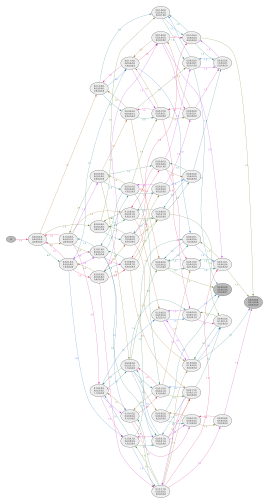

In [ ]:
import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

#| label: fig-IM-model
#| fig-cap: 'Tilstandsrum for Im-modellen som tidsinhomogen coalescent med $n=2$ prøver'
g_im.plot(max_nodes=300)

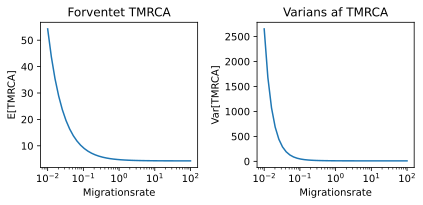

In [ ]:
#| label: fig-im-tmrca
#| fig-cap: '$\mathbb{E}[\text{TMRCA}]$ og $\text{Var}[\text{TMRCA}]$ for IM-modellen som funktion af migrationsrate ($\theta_0=0.7$). Høj migration konvergerer mod panmixi.'
#| fig-width: 6
#| fig-height: 3

theta0_im = 0.7
migration_values = np.logspace(-2, 2, 40)
E_vals_im, Var_vals_im = [], []
for m in migration_values:
    g_im.update_weights([theta0_im, m])
    E_vals_im.append(g_im.expectation())
    Var_vals_im.append(g_im.variance())

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].semilogx(migration_values, E_vals_im)
axes[0].set_xlabel('Migrationsrate'); axes[0].set_ylabel('E[TMRCA]')
axes[0].set_title('Forventet TMRCA')
axes[1].semilogx(migration_values, Var_vals_im)
axes[1].set_xlabel('Migrationsrate'); axes[1].set_ylabel('Var[TMRCA]')
axes[1].set_title('Varians af TMRCA')
plt.tight_layout(); plt.show();

## Tidsinhomogen joint probability via epoch_context

tidsinhomogen joint probability bruger `epoch_context()` og `next_ipv()`  til at kæde epoker sammen. Ved tid $t_s$ stoppes den første epoke og dens sluttilstand bruges som startvektor for den næste epoke. Dette er den korrekte måde at modellere IM-modellen på  i phasic uden at bruge `epoch_starts` i SVGD.

In [85]:
from phasic import Graph, with_ipv, StateIndexer, Property, clear_caches
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)
clear_caches()

nr_s_ctx = 4
mut_ctx = 1.0
reward_limit_ctx = 1

indexer_ctx = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_s_ctx),
    ]
)

def coal_ctx(state, indexer=None):
    transitions = []
    for i, j in all_pairs(indexer_ctx.lineage):
        p1 = indexer_ctx.lineage.index_to_props(i)
        p2 = indexer_ctx.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer_ctx.lineage.props_to_index(
            descendants=p1.descendants + p2.descendants)
        new[k] += 1
        transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

initial_ctx = [nr_s_ctx] + [0] * (nr_s_ctx - 1)
g_ctx = Graph(coal_ctx, ipv=initial_ctx, indexer=indexer_ctx)

# Joint probability graf med discrete=False
cont_joint = g_ctx.joint_prob_graph(
    reward_limit=reward_limit_ctx,
    mutation_rate=mut_ctx,
    discrete=False,
)
print(f'Continuous joint graf: {cont_joint.vertices_length()} tilstande')

  Removed 1 file(s), preserved directory structure
Continuous joint graf: 30 tilstande


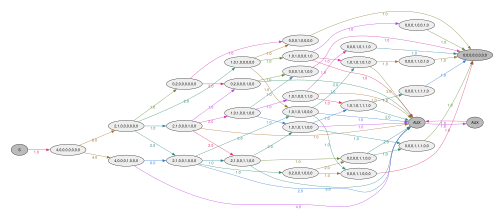

In [ ]:
#| label: fig-joint-statespace
#| fig-cap: 'Tilstandsrum for joint probability-grafen med $n=4$ og `reward_limit=2`. Hver oval repræsenterer en tilstand, der holder styr på både hvor mange linjer der er aktive og hvor mange mutationer der er sket. Pilene viser mulige overgange mellem tilstande med tilhørende rater. Processen starter i $S$ til venstre og ender i en af de grå absorberende tilstande til højre, hvor hver absorberende tilstand svarer til en unik kombination af mutationer observeret ved MRCA.'
#| fig-width: 5
#| fig-height: 3

cont_joint.plot( nodesep=0.2, max_nodes=300)

In [87]:
# Tidsinhomogen joint probability via epoch_context og next_ipv
epoch_starts_ctx = [0, 0.2, 0.5]
pop_sizes_ctx    = [1, 5, 2]

ctx = cont_joint.epoch_context()
for t, N in zip(epoch_starts_ctx[1:], pop_sizes_ctx[:-1]):
    ctx.update_weights([1/N, mut_ctx])
    epoch_ipv = ctx.next_ipv(t)
    ctx = cont_joint.epoch_context()
    ctx.update_ipv(epoch_ipv)

N = pop_sizes_ctx[-1]
ctx.update_weights([1/N, mut_ctx])
jpt = ctx.joint_probs_table()
print(f'Joint probability tabel: {len(jpt)} rækker')
print(f'Total prob: {jpt["prob"].sum():.4f}')
print(jpt.head(8).to_string())

Joint probability tabel: 8 rækker
Total prob: 0.1225
                descendants_1  descendants_2  descendants_3  descendants_4      prob
t_vertex_index                                                                      
8                           0              0              0              0  0.032500
15                          0              1              0              0  0.014725
16                          1              0              0              0  0.030323
18                          0              0              1              0  0.009060
22                          1              0              1              0  0.014373
23                          1              1              0              0  0.016132
25                          0              1              1              0  0.001646
26                          1              1              1              0  0.003716


In [88]:
ctx.joint_probs_table()

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
8,0,0,0,0,0.032500
15,0,1,0,0,0.014725
16,1,0,0,0,0.030323
18,0,0,1,0,0.009060
22,1,0,1,0,0.014373
23,1,1,0,0,0.016132
25,0,1,1,0,0.001646
26,1,1,1,0,0.003716


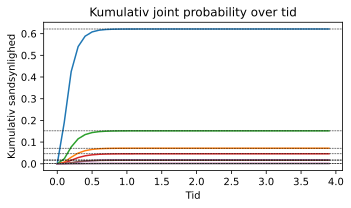

In [91]:
# Separat simpel graf til kumulativ joint probability demo
g_simple = Graph(coal_ctx, ipv=initial_ctx, indexer=indexer_ctx)
cont_simple = g_simple.joint_prob_graph(
    reward_limit=reward_limit_ctx,
    mutation_rate=mut_ctx,
    discrete=False,
)
theta_demo = [7, mut_ctx]
cont_simple.update_weights(theta_demo)

ctx_simple = cont_simple.epoch_context()
ctx_simple.update_weights(theta_demo)

t = np.arange(0, 4, 0.1)
cum_hit_probs = ctx_simple.cumulative_probs(t)

disc_simple = g_simple.joint_prob_graph(
    reward_limit=reward_limit_ctx,
    mutation_rate=mut_ctx,
    discrete=True,
)
disc_simple.update_weights(theta_demo)
asymptotes = disc_simple.joint_prob_table().prob

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(t, cum_hit_probs)
[ax.axhline(a, color='k', lw=0.5, ls='--') for a in asymptotes]
ax.set_xlabel('Tid'); ax.set_ylabel('Kumulativ sandsynlighed')
ax.set_title('Kumulativ joint probability over tid')
plt.tight_layout(); plt.show();